<a href="https://colab.research.google.com/github/hsb-ctrl-zy/multi-team1-project/blob/main/%EC%86%8C%EC%83%81%EA%B3%B5%EC%9D%B8vs%EB%8C%80%EA%B8%B0%EC%97%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 필요 라이브러리 설치 및 로드

In [ ]:
!pip install pymysql

In [ ]:
import pymysql

### SQL 연결

In [ ]:
#MySQL 연결 정보 설정
host_name='211.212.230.86'
user_name='teamuser'
password_val='1638'
db_name='geo_db'
port_num=3306

#데이터베이스 연결
conn=pymysql.connect(
    host=host_name,
    user=user_name,
    password=password_val,
    database=db_name,
    port=port_num,
    charset='utf8'
)

### MySQL 연결 상태 확인

In [ ]:
if conn:
    try:
        # 커서를 생성하여 쿼리 실행 준비
        with conn.cursor() as cursor:
            # 간단한 쿼리로 현재 연결된 데이터베이스 이름을 확인
            cursor.execute("SELECT DATABASE();")
            result = cursor.fetchone()
            if result and result[0]:
                print(f"데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: {result[0]}")
            else:
                print("데이터베이스에 연결되었지만, 현재 데이터베이스 이름을 가져올 수 없습니다.")
    except pymysql.Error as e:
        print(f"데이터베이스 연결 확인 중 오류 발생: {e}")
        print("연결에 문제가 있을 수 있습니다.")
else:
    print("데이터베이스 연결 객체(conn)가 생성되지 않았습니다. 연결이 실패했을 수 있습니다.")

데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: geo_db


### 형태소 분석을 위한 라이브러리 설치

In [ ]:
!pip install konlpy

### 데이터 로드 및 형태소 분석 준비

In [ ]:
import pandas as pd

try:
    with conn.cursor() as cursor:
        # raw_data_table에서 product_name, text_contents, brand_type, page_id 컬럼을 가져옵니다.
        sql = "SELECT product_name, text_contents, brand_type, page_id FROM raw_data_table"
        cursor.execute(sql)
        data = cursor.fetchall()

    # 데이터를 Pandas DataFrame으로 변환합니다.
    df = pd.DataFrame(data, columns=['product_name', 'text_contents', 'brand_type', 'page_id'])
    print("데이터를 성공적으로 로드했습니다. 처음 5개 행을 표시합니다:")
    display(df.head())

    print("\nbrand_type 컬럼의 고유 값과 그 개수:")
    display(df['brand_type'].value_counts())

except pymysql.Error as e:
    print(f"데이터 로드 중 오류 발생: {e}")
    df = pd.DataFrame(columns=['product_name', 'text_contents', 'brand_type', 'page_id'])

데이터를 성공적으로 로드했습니다. 처음 5개 행을 표시합니다:


,product_name,text_contents,brand_type,page_id
0,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,대기업,1
1,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,대기업,2
2,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,대기업,3
3,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,대기업,4
4,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,대기업,5



brand_type 컬럼의 고유 값과 그 개수:


,count
brand_type,
대기업,5750
소상공인,3013


### 'brand_type' 컬럼을 기준으로 데이터 분리

In [ ]:
# '대기업'과 '소상공인'으로 데이터 분리
df_large_enterprise = df[df['brand_type'] == '대기업'].copy()
df_small_business = df[df['brand_type'] == '소상공인'].copy()

print("'대기업' 데이터프레임 (df_large_enterprise) 처음 5개 행:")
display(df_large_enterprise.head())

print("\n'소상공인' 데이터프레임 (df_small_business) 처음 5개 행:")
display(df_small_business.head())

print(f"\n'대기업' 데이터 개수: {len(df_large_enterprise)}개")
print(f"'소상공인' 데이터 개수: {len(df_small_business)}개")

'대기업' 데이터프레임 (df_large_enterprise) 처음 5개 행:


,product_name,text_contents,brand_type,page_id
0,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,대기업,1
1,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,대기업,2
2,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,대기업,3
3,캘빈클라인 에센셜 셋업 3종 세트 남여공용,,대기업,4
4,7부 바지 스판 밴딩 냉장고 쿨링 아이스 냉감 칠부 츄리닝 트레이닝 팬츠,,대기업,5



'소상공인' 데이터프레임 (df_small_business) 처음 5개 행:


,product_name,text_contents,brand_type,page_id
2794,[허리잘록!/여름데이트?] 플래닝 핀턱 스트링 나시 블라우스,플래닝 핀턱 스트링 나시 블라우스\n-체형에 맞춰 조절 가능한 끈 길이\n- 허리 ...,소상공인,2816
2795,[팔뚝삭제/허얇핏] 앤드리 도트 콩단추 반팔 블라우스,앤드리 도트 콩단추 반팔 블라우스\n- 러블리한 도트 패턴으로 포인트를 더한 블라우...,소상공인,2817
2796,*7col [햇빛막아주는/여리!] 파파야 시스루 썸머 루즈핏 셔츠,파파야 시스루 썸머 루즈핏 셔츠\n- 체형에 구애 없는 루즈핏 실루엣\n- 힙을 덮...,소상공인,2818
2797,[여리여리-/부유방부각X] 슈디 캉캉 나시 블라우스,슈디 캉캉 나시 블라우스\n- 은은하게 비치는 쉬폰 소재로 여리여리한 무드\n-캉캉...,소상공인,2819
2798,[여름내내/힙덮는] 먼데이 린넨 스트라이프 루즈핏 셔츠,먼데이 린넨 스트라이프 루즈핏 셔츠\n- 여름시즌 활용하기 좋은 린넨 원단\n- 루...,소상공인,2820



'대기업' 데이터 개수: 5750개
'소상공인' 데이터 개수: 3013개


#### 형태소 분석기 정의

Okt 정의

In [ ]:
from konlpy.tag import Okt
import re

okt = Okt()

# --- 특수문자 비율 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Okt Functions ---
def get_pos_ratios(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = okt.pos(text)
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag in pos_tags if tag == 'Noun')
    adjective_count = sum(1 for word, tag in pos_tags if tag == 'Adjective')
    numeral_count = sum(1 for word, tag in pos_tags if tag == 'Number')
    verb_count = sum(1 for word, tag in pos_tags if tag == 'Verb')
    josa_count = sum(1 for word, tag in pos_tags if tag == 'Josa')
    eomi_count = sum(1 for word, tag in pos_tags if tag == 'Eomi')

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

print("Okt 형태소 분석기 및 비율 계산 함수 정의 완료.")

Okt 형태소 분석기 및 비율 계산 함수 정의 완료.


KKma 정의

In [ ]:
from konlpy.tag import Kkma
import re

kkma = Kkma()

# --- 특수문자 비율 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Kkma Functions ---
def get_pos_ratios_kkma(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = kkma.pos(text)
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag in pos_tags if tag.startswith('N'))
    adjective_count = sum(1 for word, tag in pos_tags if tag == 'VA')
    numeral_count = sum(1 for word, tag in pos_tags if tag == 'NR')
    verb_count = sum(1 for word, tag in pos_tags if tag == 'VV')
    josa_count = sum(1 for word, tag in pos_tags if tag.startswith('J'))
    eomi_count = sum(1 for word, tag in pos_tags if tag.startswith('E'))

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

def get_special_char_ratio_kkma(text):
    return get_special_char_ratio(text)

print("Kkma 형태소 분석기 및 비율 계산 함수 정의 완료.")

Kkma 형태소 분석기 및 비율 계산 함수 정의 완료.


Komoran 정의

In [ ]:
from konlpy.tag import Komoran
import re

komoran=Komoran()

# --- 특수문자 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Komoran Functions ---
def get_pos_ratios_komoran(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = komoran.pos(text)
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag in pos_tags if tag.startswith('N'))
    adjective_count = sum(1 for word, tag in pos_tags if tag == 'VA')
    numeral_count = sum(1 for word, tag in pos_tags if tag == 'NR')
    verb_count = sum(1 for word, tag in pos_tags if tag == 'VV')
    josa_count = sum(1 for word, tag in pos_tags if tag.startswith('J'))
    eomi_count = sum(1 for word, tag in pos_tags if tag.startswith('E'))

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

def get_special_char_ratio_komoran(text):
    return get_special_char_ratio(text)

print("Komoran 형태소 분석기 및 비율 계산 함수 정의 완료.")

Komoran 형태소 분석기 및 비율 계산 함수 정의 완료.


Kiwi 정의

In [ ]:
!pip install kiwipiepy

In [ ]:
from kiwipiepy import Kiwi
import re

kiwi = Kiwi()

# --- 특수문자 function (common for all) ---
def get_special_char_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return {'special_char_ratio': 0, 'total_char_count': 0}

    total_char_count = len(text)
    if total_char_count == 0:
        return {'special_char_ratio': 0, 'total_char_count': 0}

    # 한글, 영어, 숫자를 제외한 모든 문자를 특수문자로 간주
    special_char_count = len(re.findall(r'[^\s\w가-힣]', text))

    return {
        'special_char_ratio': special_char_count / total_char_count,
        'total_char_count': total_char_count
    }

# --- Kiwi Functions ---
def get_pos_ratios_kiwi(text):
    if not isinstance(text, str) or not text.strip():
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    result = kiwi.analyze(text)
    if not result or not result[0]:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    pos_tags = result[0][0]
    total_pos_count = len(pos_tags)

    if total_pos_count == 0:
        return {'noun_ratio': 0, 'adjective_ratio': 0, 'numeral_ratio': 0, 'verb_ratio': 0, 'josa_ratio': 0, 'eomi_ratio': 0, 'total_pos_count': 0}

    noun_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('N'))
    adjective_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('VA'))
    numeral_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('NR'))
    verb_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('V'))
    josa_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('J'))
    eomi_count = sum(1 for word, tag, _, _ in pos_tags if tag.startswith('E'))

    return {
        'noun_ratio': noun_count / total_pos_count,
        'adjective_ratio': adjective_count / total_pos_count,
        'numeral_ratio': numeral_count / total_pos_count,
        'verb_ratio': verb_count / total_pos_count,
        'josa_ratio': josa_count / total_pos_count,
        'eomi_ratio': eomi_count / total_pos_count,
        'total_pos_count': total_pos_count
    }

def get_special_char_ratio_kiwi(text):
    return get_special_char_ratio(text)

print("Kiwi 형태소 분석기 및 비율 계산 함수 정의 완료.")

Kiwi 형태소 분석기 및 비율 계산 함수 정의 완료.


#### Okt 형태소 분석 - '대기업' 및 '소상공인' 데이터에 적용

In [ ]:
# df_large_enterprise에 Okt 형태소 분석 적용
def apply_okt_analysis_to_df(df_target):
    # product_name 컬럼에 형태소 분석 함수 적용
    product_name_pos_results = df_target['product_name'].apply(get_pos_ratios)
    df_target['product_name_noun_ratio'] = product_name_pos_results.apply(lambda x: x['noun_ratio'])
    df_target['product_name_adjective_ratio'] = product_name_pos_results.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_numeral_ratio'] = product_name_pos_results.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_verb_ratio'] = product_name_pos_results.apply(lambda x: x['verb_ratio'])
    df_target['product_name_josa_ratio'] = product_name_pos_results.apply(lambda x: x['josa_ratio'])
    df_target['product_name_eomi_ratio'] = product_name_pos_results.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용
    product_name_special_char_results = df_target['product_name'].apply(get_special_char_ratio)
    df_target['product_name_special_char_ratio'] = product_name_special_char_results.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 형태소 분석 함수 적용
    text_contents_pos_results = df_target['text_contents'].apply(get_pos_ratios)
    df_target['text_contents_noun_ratio'] = text_contents_pos_results.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_adjective_ratio'] = text_contents_pos_results.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_numeral_ratio'] = text_contents_pos_results.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_verb_ratio'] = text_contents_pos_results.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_josa_ratio'] = text_contents_pos_results.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_eomi_ratio'] = text_contents_pos_results.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용
    text_contents_special_char_results = df_target['text_contents'].apply(get_special_char_ratio)
    df_target['text_contents_special_char_ratio'] = text_contents_special_char_results.apply(lambda x: x['special_char_ratio'])
    return df_target

df_large_enterprise = apply_okt_analysis_to_df(df_large_enterprise.copy())
df_small_business = apply_okt_analysis_to_df(df_small_business.copy())

print("Okt 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")

Okt 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


#### Kkma 형태소 분석 - '대기업' 및 '소상공인' 데이터에 적용

In [ ]:
# df_large_enterprise에 Kkma 형태소 분석 적용
def apply_kkma_analysis_to_df(df_target):
    # product_name 컬럼에 Kkma 형태소 분석 함수 적용
    product_name_pos_results_kkma = df_target['product_name'].apply(get_pos_ratios_kkma)
    df_target['product_name_kkma_noun_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['noun_ratio'])
    df_target['product_name_kkma_adjective_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_kkma_numeral_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_kkma_verb_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['verb_ratio'])
    df_target['product_name_kkma_josa_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['josa_ratio'])
    df_target['product_name_kkma_eomi_ratio'] = product_name_pos_results_kkma.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용 (Kkma 버전)
    product_name_special_char_results_kkma = df_target['product_name'].apply(get_special_char_ratio_kkma)
    df_target['product_name_kkma_special_char_ratio'] = product_name_special_char_results_kkma.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 Kkma 형태소 분석 함수 적용
    text_contents_pos_results_kkma = df_target['text_contents'].apply(get_pos_ratios_kkma)
    df_target['text_contents_kkma_noun_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_kkma_adjective_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_kkma_numeral_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_kkma_verb_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_kkma_josa_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_kkma_eomi_ratio'] = text_contents_pos_results_kkma.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용 (Kkma 버전)
    text_contents_special_char_results_kkma = df_target['text_contents'].apply(get_special_char_ratio_kkma)
    df_target['text_contents_kkma_special_char_ratio'] = text_contents_special_char_results_kkma.apply(lambda x: x['special_char_ratio'])
    return df_target

df_large_enterprise = apply_kkma_analysis_to_df(df_large_enterprise.copy())
df_small_business = apply_kkma_analysis_to_df(df_small_business.copy())

print("Kkma 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")

Kkma 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


#### Komoran 형태소 분석 - '대기업' 및 '소상공인' 데이터에 적용

In [ ]:
# df_large_enterprise에 Komoran 형태소 분석 적용
def apply_komoran_analysis_to_df(df_target):
    # product_name 컬럼에 Komoran 형태소 분석 함수 적용
    product_name_pos_results_komoran = df_target['product_name'].apply(get_pos_ratios_komoran)
    df_target['product_name_komoran_noun_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['noun_ratio'])
    df_target['product_name_komoran_adjective_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_komoran_numeral_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_komoran_verb_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['verb_ratio'])
    df_target['product_name_komoran_josa_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['josa_ratio'])
    df_target['product_name_komoran_eomi_ratio'] = product_name_pos_results_komoran.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용 (Komoran 버전)
    product_name_special_char_results_komoran = df_target['product_name'].apply(get_special_char_ratio_komoran)
    df_target['product_name_komoran_special_char_ratio'] = product_name_special_char_results_komoran.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 Komoran 형태소 분석 함수 적용
    text_contents_pos_results_komoran = df_target['text_contents'].apply(get_pos_ratios_komoran)
    df_target['text_contents_komoran_noun_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_komoran_adjective_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_komoran_numeral_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_komoran_verb_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_komoran_josa_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_komoran_eomi_ratio'] = text_contents_pos_results_komoran.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용 (Komoran 버전)
    text_contents_special_char_results_komoran = df_target['text_contents'].apply(get_special_char_ratio_komoran)
    df_target['text_contents_komoran_special_char_ratio'] = text_contents_special_char_results_komoran.apply(lambda x: x['special_char_ratio'])
    return df_target

df_large_enterprise = apply_komoran_analysis_to_df(df_large_enterprise.copy())
df_small_business = apply_komoran_analysis_to_df(df_small_business.copy())

print("Komoran 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")

Komoran 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


#### Kiwi 형태소 분석 - '대기업' 및 '소상공인' 데이터에 적용

In [ ]:
# df_large_enterprise에 Kiwi 형태소 분석 적용
def apply_kiwi_analysis_to_df(df_target):
    # product_name 컬럼에 Kiwi 형태소 분석 함수 적용
    product_name_pos_results_kiwi = df_target['product_name'].apply(get_pos_ratios_kiwi)
    df_target['product_name_kiwi_noun_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['noun_ratio'])
    df_target['product_name_kiwi_adjective_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['adjective_ratio'])
    df_target['product_name_kiwi_numeral_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['numeral_ratio'])
    df_target['product_name_kiwi_verb_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['verb_ratio'])
    df_target['product_name_kiwi_josa_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['josa_ratio'])
    df_target['product_name_kiwi_eomi_ratio'] = product_name_pos_results_kiwi.apply(lambda x: x['eomi_ratio'])

    # product_name 컬럼에 특수문자 비율 함수 적용 (Kiwi 버전)
    product_name_special_char_results_kiwi = df_target['product_name'].apply(get_special_char_ratio_kiwi)
    df_target['product_name_kiwi_special_char_ratio'] = product_name_special_char_results_kiwi.apply(lambda x: x['special_char_ratio'])

    # text_contents 컬럼에 Kiwi 형태소 분석 함수 적용
    text_contents_pos_results_kiwi = df_target['text_contents'].apply(get_pos_ratios_kiwi)
    df_target['text_contents_kiwi_noun_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['noun_ratio'])
    df_target['text_contents_kiwi_adjective_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['adjective_ratio'])
    df_target['text_contents_kiwi_numeral_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['numeral_ratio'])
    df_target['text_contents_kiwi_verb_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['verb_ratio'])
    df_target['text_contents_kiwi_josa_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['josa_ratio'])
    df_target['text_contents_kiwi_eomi_ratio'] = text_contents_pos_results_kiwi.apply(lambda x: x['eomi_ratio'])

    # text_contents 컬럼에 특수문자 비율 함수 적용 (Kiwi 버전)
    text_contents_special_char_results_kiwi = df_target['text_contents'].apply(get_special_char_ratio_kiwi)
    df_target['text_contents_kiwi_special_char_ratio'] = text_contents_special_char_results_kiwi.apply(lambda x: x['special_char_ratio'])
    return df_target

df_large_enterprise = apply_kiwi_analysis_to_df(df_large_enterprise.copy())
df_small_business = apply_kiwi_analysis_to_df(df_small_business.copy())

print("Kiwi 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.")

Kiwi 분석을 이용한 '대기업' 및 '소상공인' 데이터의 형태소 분석 및 특수문자 비율 계산 완료.


#### '대기업' 데이터 분석 결과 (한글 컬럼명)

In [ ]:
# '대기업' 데이터의 모든 분석 결과 컬럼들을 통합하여 표시
# Okt, Kkma, Komoran, Kiwi 분석 결과를 포함

# 'product_name' 관련 컬럼
product_name_cols_large = [
    'product_name_noun_ratio', 'product_name_adjective_ratio', 'product_name_numeral_ratio', 'product_name_verb_ratio', 'product_name_josa_ratio', 'product_name_eomi_ratio', 'product_name_special_char_ratio',
    'product_name_kkma_noun_ratio', 'product_name_kkma_adjective_ratio', 'product_name_kkma_numeral_ratio', 'product_name_kkma_verb_ratio', 'product_name_kkma_josa_ratio', 'product_name_kkma_eomi_ratio', 'product_name_kkma_special_char_ratio',
    'product_name_komoran_noun_ratio', 'product_name_komoran_adjective_ratio', 'product_name_komoran_numeral_ratio', 'product_name_komoran_verb_ratio', 'product_name_komoran_josa_ratio', 'product_name_komoran_eomi_ratio', 'product_name_komoran_special_char_ratio',
    'product_name_kiwi_noun_ratio', 'product_name_kiwi_adjective_ratio', 'product_name_kiwi_numeral_ratio', 'product_name_kiwi_verb_ratio', 'product_name_kiwi_josa_ratio', 'product_name_kiwi_eomi_ratio', 'product_name_kiwi_special_char_ratio'
]

# 'text_contents' 관련 컬럼
text_contents_cols_large = [
    'text_contents_noun_ratio', 'text_contents_adjective_ratio', 'text_contents_numeral_ratio', 'text_contents_verb_ratio', 'text_contents_josa_ratio', 'text_contents_eomi_ratio', 'text_contents_special_char_ratio',
    'text_contents_kkma_noun_ratio', 'text_contents_kkma_adjective_ratio', 'text_contents_kkma_numeral_ratio', 'text_contents_kkma_verb_ratio', 'text_contents_kkma_josa_ratio', 'text_contents_kkma_eomi_ratio', 'text_contents_kkma_special_char_ratio',
    'text_contents_komoran_noun_ratio', 'text_contents_komoran_adjective_ratio', 'text_contents_komoran_numeral_ratio', 'text_contents_komoran_verb_ratio', 'text_contents_komoran_josa_ratio', 'text_contents_komoran_eomi_ratio', 'text_contents_komoran_special_char_ratio',
    'text_contents_kiwi_noun_ratio', 'text_contents_kiwi_adjective_ratio', 'text_contents_kiwi_numeral_ratio', 'text_contents_kiwi_verb_ratio', 'text_contents_kiwi_josa_ratio', 'text_contents_kiwi_eomi_ratio', 'text_contents_kiwi_special_char_ratio'
]

# 필요한 컬럼만 선택하여 새로운 DataFrame 생성
df_large_enterprise_display = df_large_enterprise[['product_name', 'text_contents'] + product_name_cols_large + text_contents_cols_large].copy()

# 한글 컬럼명 매핑
column_name_mapping = {
    'product_name': '상품명',
    'text_contents': '본문',

    'product_name_noun_ratio': '상품명_Okt_명사_비율',
    'product_name_adjective_ratio': '상품명_Okt_형용사_비율',
    'product_name_numeral_ratio': '상품명_Okt_수사_비율',
    'product_name_verb_ratio': '상품명_Okt_동사_비율',
    'product_name_josa_ratio': '상품명_Okt_조사_비율',
    'product_name_eomi_ratio': '상품명_Okt_어미_비율',
    'product_name_special_char_ratio': '상품명_Okt_특수문자_비율',

    'product_name_kkma_noun_ratio': '상품명_Kkma_명사_비율',
    'product_name_kkma_adjective_ratio': '상품명_Kkma_형용사_비율',
    'product_name_kkma_numeral_ratio': '상품명_Kkma_수사_비율',
    'product_name_kkma_verb_ratio': '상품명_Kkma_동사_비율',
    'product_name_kkma_josa_ratio': '상품명_Kkma_조사_비율',
    'product_name_kkma_eomi_ratio': '상품명_Kkma_어미_비율',
    'product_name_kkma_special_char_ratio': '상품명_Kkma_특수문자_비율',

    'product_name_komoran_noun_ratio': '상품명_Komoran_명사_비율',
    'product_name_komoran_adjective_ratio': '상품명_Komoran_형용사_비율',
    'product_name_komoran_numeral_ratio': '상품명_Komoran_수사_비율',
    'product_name_komoran_verb_ratio': '상품명_Komoran_동사_비율',
    'product_name_komoran_josa_ratio': '상품명_Komoran_조사_비율',
    'product_name_komoran_eomi_ratio': '상품명_Komoran_어미_비율',
    'product_name_komoran_special_char_ratio': '상품명_Komoran_특수문자_비율',

    'product_name_kiwi_noun_ratio': '상품명_Kiwi_명사_비율',
    'product_name_kiwi_adjective_ratio': '상품명_Kiwi_형용사_비율',
    'product_name_kiwi_numeral_ratio': '상품명_Kiwi_수사_비율',
    'product_name_kiwi_verb_ratio': '상품명_Kiwi_동사_비율',
    'product_name_kiwi_josa_ratio': '상품명_Kiwi_조사_비율',
    'product_name_kiwi_eomi_ratio': '상품명_Kiwi_어미_비율',
    'product_name_kiwi_special_char_ratio': '상품명_Kiwi_특수문자_비율',


    'text_contents_noun_ratio': '본문_Okt_명사_비율',
    'text_contents_adjective_ratio': '본문_Okt_형용사_비율',
    'text_contents_numeral_ratio': '본문_Okt_수사_비율',
    'text_contents_verb_ratio': '본문_Okt_동사_비율',
    'text_contents_josa_ratio': '본문_Okt_조사_비율',
    'text_contents_eomi_ratio': '본문_Okt_어미_비율',
    'text_contents_special_char_ratio': '본문_Okt_특수문자_비율',

    'text_contents_kkma_noun_ratio': '본문_Kkma_명사_비율',
    'text_contents_kkma_adjective_ratio': '본문_Kkma_형용사_비율',
    'text_contents_kkma_numeral_ratio': '본문_Kkma_수사_비율',
    'text_contents_kkma_verb_ratio': '본문_Kkma_동사_비율',
    'text_contents_kkma_josa_ratio': '본문_Kkma_조사_비율',
    'text_contents_kkma_eomi_ratio': '본문_Kkma_어미_비율',
    'text_contents_kkma_special_char_ratio': '본문_Kkma_특수문자_비율',

    'text_contents_komoran_noun_ratio': '본문_Komoran_명사_비율',
    'text_contents_komoran_adjective_ratio': '본문_Komoran_형용사_비율',
    'text_contents_komoran_numeral_ratio': '본문_Komoran_수사_비율',
    'text_contents_komoran_verb_ratio': '본문_Komoran_동사_비율',
    'text_contents_komoran_josa_ratio': '본문_Komoran_조사_비율',
    'text_contents_komoran_eomi_ratio': '본문_Komoran_어미_비율',
    'text_contents_komoran_special_char_ratio': '본문_Komoran_특수문자_비율',

    'text_contents_kiwi_noun_ratio': '본문_Kiwi_명사_비율',
    'text_contents_kiwi_adjective_ratio': '본문_Kiwi_형용사_비율',
    'text_contents_kiwi_numeral_ratio': '본문_Kiwi_수사_비율',
    'text_contents_kiwi_verb_ratio': '본문_Kiwi_동사_비율',
    'text_contents_kiwi_josa_ratio': '본문_Kiwi_조사_비율',
    'text_contents_kiwi_eomi_ratio': '본문_Kiwi_어미_비율',
    'text_contents_kiwi_special_char_ratio': '본문_Kiwi_특수문자_비율'
}

df_large_enterprise_display = df_large_enterprise_display.rename(columns=column_name_mapping)

print("'대기업' 데이터 분석 결과 (상위 3개 행):")
display(df_large_enterprise_display.head(3))

'대기업' 데이터 분석 결과 (상위 3개 행):


,상품명,본문,상품명_Okt_명사_비율,상품명_Okt_형용사_비율,상품명_Okt_수사_비율,상품명_Okt_동사_비율,상품명_Okt_조사_비율,상품명_Okt_어미_비율,상품명_Okt_특수문자_비율,상품명_Kkma_명사_비율,...,본문_Komoran_조사_비율,본문_Komoran_어미_비율,본문_Komoran_특수문자_비율,본문_Kiwi_명사_비율,본문_Kiwi_형용사_비율,본문_Kiwi_수사_비율,본문_Kiwi_동사_비율,본문_Kiwi_조사_비율,본문_Kiwi_어미_비율,본문_Kiwi_특수문자_비율
0,남성 쿨 원턱 와이드 트레이닝팬츠 PHG2PT1759,,0.545455,0.0,0.181818,0.0,0.000000,0.0,0.0,0.666667,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000
1,트레이닝 반바지 249PT262,[엔비에이][NBA] 스몰로고 트레이닝 반바지(N262TP942P)\n시그니처 로고...,0.400000,0.0,0.400000,0.0,0.000000,0.0,0.0,0.800000,...,0.110187,0.139293,0.03578,0.388889,0.032051,0.0,0.064103,0.119658,0.143162,0.03578
2,남성 여성 커플 냉장고바지 쿨팬츠 8부 9부 아이스바지,,0.750000,0.0,0.166667,0.0,0.083333,0.0,0.0,0.857143,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000


#### '소상공인' 데이터 분석 결과 (한글 컬럼명)

In [ ]:
# '소상공인' 데이터의 모든 분석 결과 컬럼들을 통합하여 표시
# Okt, Kkma, Komoran, Kiwi 분석 결과를 포함

# 필요한 컬럼만 선택하여 새로운 DataFrame 생성
df_small_business_display = df_small_business[['product_name', 'text_contents'] + product_name_cols_large + text_contents_cols_large].copy()

# 한글 컬럼명 매핑 (동일한 매핑 사용)
df_small_business_display = df_small_business_display.rename(columns=column_name_mapping)

print("'소상공인' 데이터 분석 결과 (상위 3개 행):")
display(df_small_business_display.head(3))

'소상공인' 데이터 분석 결과 (상위 3개 행):


,상품명,본문,상품명_Okt_명사_비율,상품명_Okt_형용사_비율,상품명_Okt_수사_비율,상품명_Okt_동사_비율,상품명_Okt_조사_비율,상품명_Okt_어미_비율,상품명_Okt_특수문자_비율,상품명_Kkma_명사_비율,...,본문_Komoran_조사_비율,본문_Komoran_어미_비율,본문_Komoran_특수문자_비율,본문_Kiwi_명사_비율,본문_Kiwi_형용사_비율,본문_Kiwi_수사_비율,본문_Kiwi_동사_비율,본문_Kiwi_조사_비율,본문_Kiwi_어미_비율,본문_Kiwi_특수문자_비율
2794,[허리잘록!/여름데이트?] 플래닝 핀턱 스트링 나시 블라우스,플래닝 핀턱 스트링 나시 블라우스\n-체형에 맞춰 조절 가능한 끈 길이\n- 허리 ...,0.666667,0.000000,0.000000,0.000000,0.0,0.0,0.151515,0.571429,...,0.079208,0.118812,0.056522,0.435644,0.019802,0.0,0.079208,0.059406,0.118812,0.056522
2795,[팔뚝삭제/허얇핏] 앤드리 도트 콩단추 반팔 블라우스,앤드리 도트 콩단추 반팔 블라우스\n- 러블리한 도트 패턴으로 포인트를 더한 블라우...,0.714286,0.000000,0.000000,0.000000,0.0,0.0,0.103448,0.642857,...,0.079208,0.099010,0.049793,0.463158,0.021053,0.0,0.042105,0.073684,0.094737,0.049793
2796,*7col [햇빛막아주는/여리!] 파파야 시스루 썸머 루즈핏 셔츠,파파야 시스루 썸머 루즈핏 셔츠\n- 체형에 구애 없는 루즈핏 실루엣\n- 힙을 덮...,0.466667,0.066667,0.066667,0.066667,0.0,0.0,0.138889,0.380952,...,0.074074,0.101852,0.070866,0.427273,0.036364,0.0,0.081818,0.072727,0.100000,0.070866


#### '대기업'과 '소상공인' 데이터 형태소 분석기별 평균 비율 비교

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 각 형태소 분석기별 평균 비율 계산 함수
def calculate_average_ratios_by_analyzer(df_target, prefix_base, analyzer_suffix=""):
    columns_to_avg = [
        f'{prefix_base}{analyzer_suffix}_noun_ratio',
        f'{prefix_base}{analyzer_suffix}_adjective_ratio',
        f'{prefix_base}{analyzer_suffix}_numeral_ratio',
        f'{prefix_base}{analyzer_suffix}_verb_ratio',
        f'{prefix_base}{analyzer_suffix}_josa_ratio',
        f'{prefix_base}{analyzer_suffix}_eomi_ratio',
        f'{prefix_base}{analyzer_suffix}_special_char_ratio'
    ]
    avg_ratios = df_target[columns_to_avg].mean().to_dict()
    return {k.replace(f'{prefix_base}{analyzer_suffix}_', ''): v for k, v in avg_ratios.items()}

# '대기업' 데이터 평균 비율 계산
avg_large_okt_product_name = calculate_average_ratios_by_analyzer(df_large_enterprise, 'product_name')
avg_large_okt_text_contents = calculate_average_ratios_by_analyzer(df_large_enterprise, 'text_contents')
avg_large_kkma_product_name = calculate_average_ratios_by_analyzer(df_large_enterprise, 'product_name', '_kkma')
avg_large_kkma_text_contents = calculate_average_ratios_by_analyzer(df_large_enterprise, 'text_contents', '_kkma')
avg_large_komoran_product_name = calculate_average_ratios_by_analyzer(df_large_enterprise, 'product_name', '_komoran')
avg_large_komoran_text_contents = calculate_average_ratios_by_analyzer(df_large_enterprise, 'text_contents', '_komoran')
avg_large_kiwi_product_name = calculate_average_ratios_by_analyzer(df_large_enterprise, 'product_name', '_kiwi')
avg_large_kiwi_text_contents = calculate_average_ratios_by_analyzer(df_large_enterprise, 'text_contents', '_kiwi')

# '소상공인' 데이터 평균 비율 계산
avg_small_okt_product_name = calculate_average_ratios_by_analyzer(df_small_business, 'product_name')
avg_small_okt_text_contents = calculate_average_ratios_by_analyzer(df_small_business, 'text_contents')
avg_small_kkma_product_name = calculate_average_ratios_by_analyzer(df_small_business, 'product_name', '_kkma')
avg_small_kkma_text_contents = calculate_average_ratios_by_analyzer(df_small_business, 'text_contents', '_kkma')
avg_small_komoran_product_name = calculate_average_ratios_by_analyzer(df_small_business, 'product_name', '_komoran')
avg_small_komoran_text_contents = calculate_average_ratios_by_analyzer(df_small_business, 'text_contents', '_komoran')
avg_small_kiwi_product_name = calculate_average_ratios_by_analyzer(df_small_business, 'product_name', '_kiwi')
avg_small_kiwi_text_contents = calculate_average_ratios_by_analyzer(df_small_business, 'text_contents', '_kiwi')

print("'대기업' 및 '소상공인' 데이터의 형태소 분석기별 평균 비율 계산 완료.")

'대기업' 및 '소상공인' 데이터의 형태소 분석기별 평균 비율 계산 완료.


#### '상품명' 품사별 평균 비율 비교 ('대기업' vs '소상공인') 시각화

In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [ ]:
### Matplotlib 한글 폰트 설정 (깨짐 방지)

import matplotlib.pyplot as plt
import platform

# 운영체제에 맞는 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib 한글 폰트 설정 완료.")

Matplotlib 한글 폰트 설정 완료.


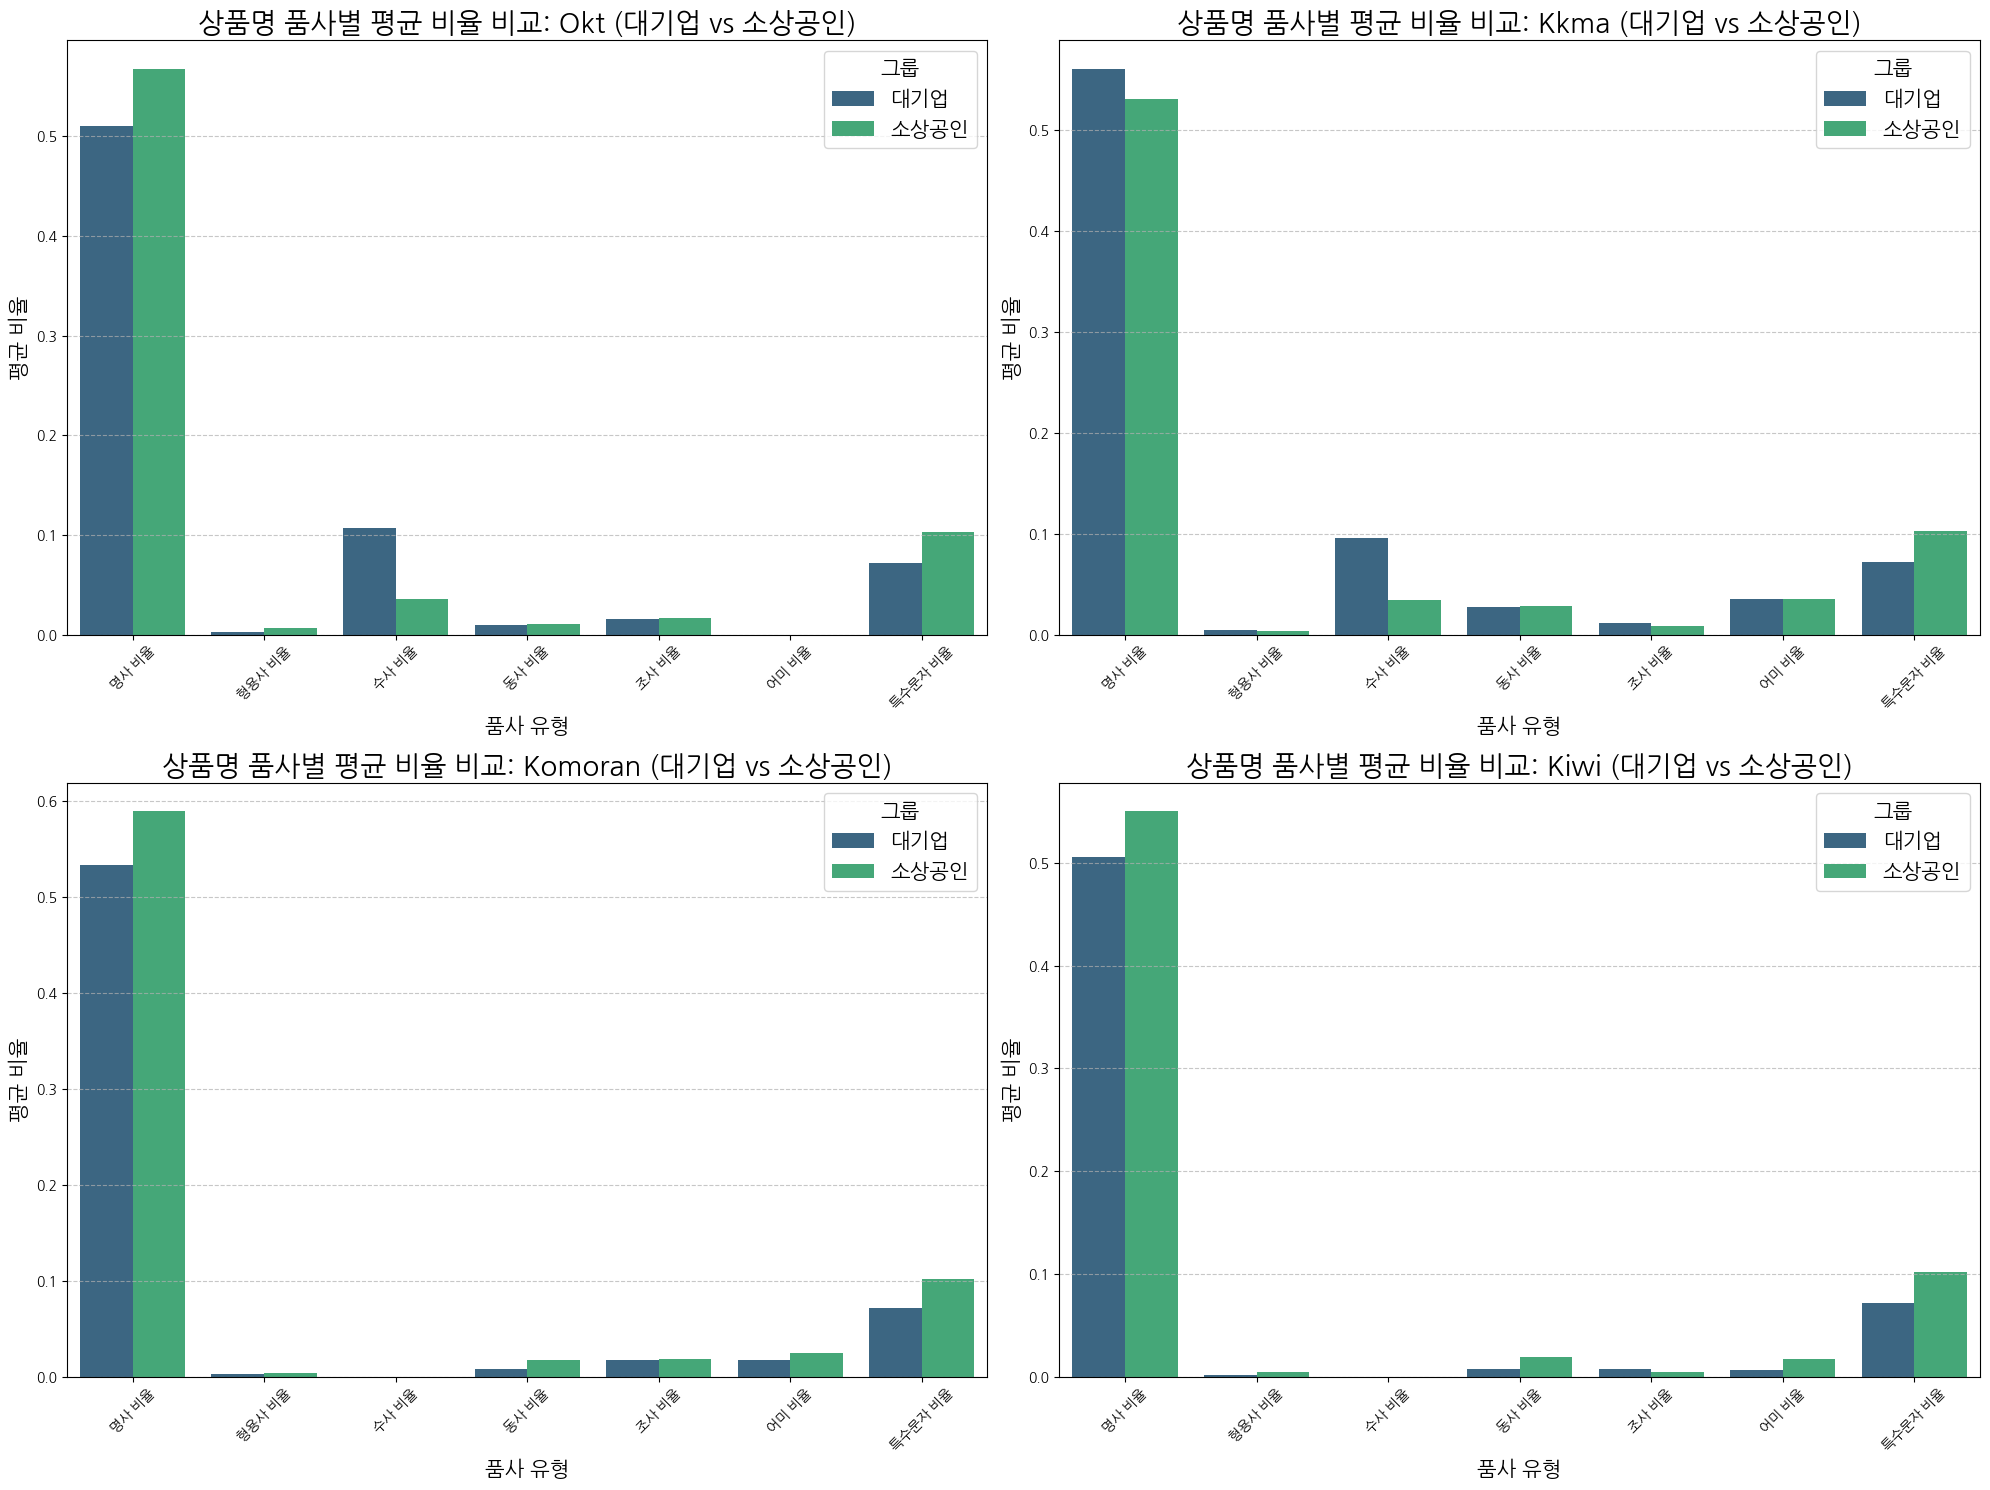

In [ ]:
# '상품명' 데이터를 플로팅을 위한 DataFrame으로 변환
product_name_ratios_large_df = pd.DataFrame({
    'Okt': avg_large_okt_product_name,
    'Kkma': avg_large_kkma_product_name,
    'Komoran': avg_large_komoran_product_name,
    'Kiwi': avg_large_kiwi_product_name
}).drop('total_pos_count', errors='ignore')
product_name_ratios_small_df = pd.DataFrame({
    'Okt': avg_small_okt_product_name,
    'Kkma': avg_small_kkma_product_name,
    'Komoran': avg_small_komoran_product_name,
    'Kiwi': avg_small_kiwi_product_name
}).drop('total_pos_count', errors='ignore')

# Dataframe for '대기업'
product_name_ratios_large_melted = product_name_ratios_large_df.T.reset_index().melt(id_vars='index')
product_name_ratios_large_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
product_name_ratios_large_melted['Group'] = '대기업'

# Dataframe for '소상공인'
product_name_ratios_small_melted = product_name_ratios_small_df.T.reset_index().melt(id_vars='index')
product_name_ratios_small_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
product_name_ratios_small_melted['Group'] = '소상공인'

# 두 그룹 병합
product_name_comparison_df = pd.concat([product_name_ratios_large_melted, product_name_ratios_small_melted])

# 한글 품사명으로 변경
pos_type_mapping = {
    'noun_ratio': '명사 비율',
    'adjective_ratio': '형용사 비율',
    'numeral_ratio': '수사 비율',
    'verb_ratio': '동사 비율',
    'josa_ratio': '조사 비율',
    'eomi_ratio': '어미 비율',
    'special_char_ratio': '특수문자 비율'
}
product_name_comparison_df['POS_Type'] = product_name_comparison_df['POS_Type'].replace(pos_type_mapping);

# 요청된 순서대로 정렬
ordered_pos_types = ['명사 비율', '형용사 비율', '수사 비율', '동사 비율', '조사 비율', '어미 비율', '특수문자 비율']
product_name_comparison_df['POS_Type'] = pd.Categorical(product_name_comparison_df['POS_Type'], categories=ordered_pos_types, ordered=True)
product_name_comparison_df = product_name_comparison_df.sort_values('POS_Type')

# 각 형태소 분석기별로 그래프 생성 (Subplots 사용)
analyzers = ['Okt', 'Kkma', 'Komoran', 'Kiwi'] # analyzers가 이미 정의되어 있다면 제거해도 됨

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten() # 2x2 grid to 1D array for easy iteration

for i, analyzer in enumerate(analyzers):
    sns.barplot(x='POS_Type', y='Average_Ratio', hue='Group', data=product_name_comparison_df[product_name_comparison_df['Analyzer'] == analyzer], palette='viridis', ax=axes[i])
    axes[i].set_title(f'상품명 품사별 평균 비율 비교: {analyzer} (대기업 vs 소상공인)', fontsize=20)
    axes[i].set_xlabel('품사 유형', fontsize=15)
    axes[i].set_ylabel('평균 비율', fontsize=15)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='그룹', title_fontsize=15, fontsize=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('대기업vs소상공인_품사_상품명.png')

plt.show()

#### '본문' 품사별 평균 비율 비교 ('대기업' vs '소상공인') 시각화

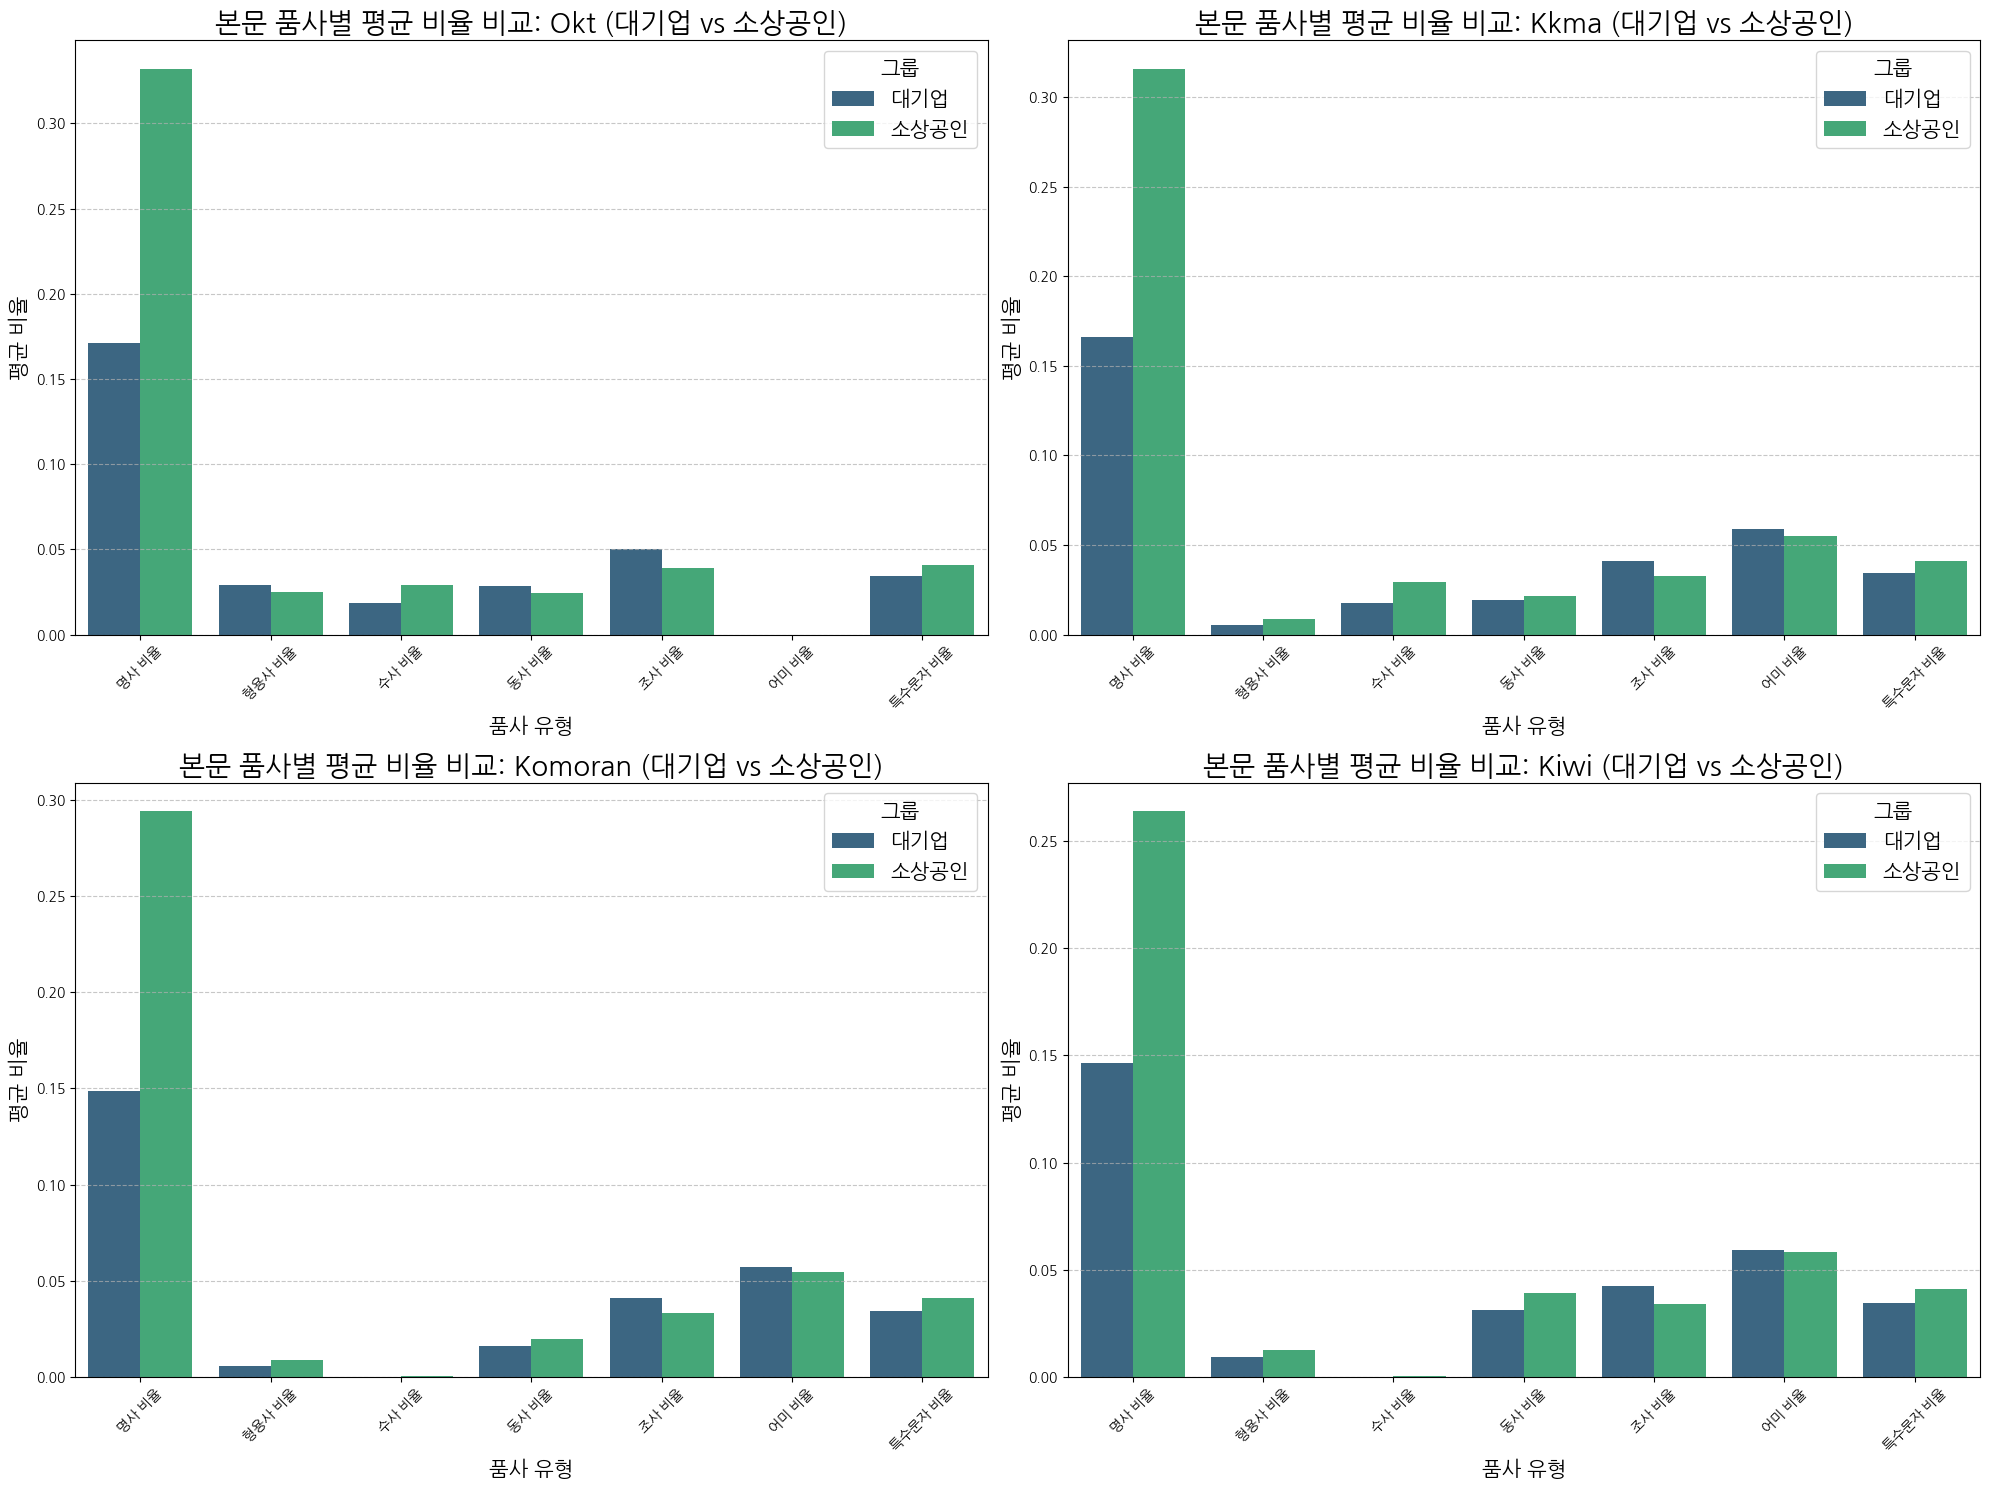

In [ ]:
# '본문' 데이터를 플로팅을 위한 DataFrame으로 변환
text_contents_ratios_large_df = pd.DataFrame({
    'Okt': avg_large_okt_text_contents,
    'Kkma': avg_large_kkma_text_contents,
    'Komoran': avg_large_komoran_text_contents,
    'Kiwi': avg_large_kiwi_text_contents
}).drop('total_pos_count', errors='ignore')
text_contents_ratios_small_df = pd.DataFrame({
    'Okt': avg_small_okt_text_contents,
    'Kkma': avg_small_kkma_text_contents,
    'Komoran': avg_small_komoran_text_contents,
    'Kiwi': avg_small_kiwi_text_contents
}).drop('total_pos_count', errors='ignore')

# Dataframe for '대기업'
text_contents_ratios_large_melted = text_contents_ratios_large_df.T.reset_index().melt(id_vars='index')
text_contents_ratios_large_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
text_contents_ratios_large_melted['Group'] = '대기업'

# Dataframe for '소상공인'
text_contents_ratios_small_melted = text_contents_ratios_small_df.T.reset_index().melt(id_vars='index')
text_contents_ratios_small_melted.columns = ['Analyzer', 'POS_Type', 'Average_Ratio']
text_contents_ratios_small_melted['Group'] = '소상공인'

# 두 그룹 병합
text_contents_comparison_df = pd.concat([text_contents_ratios_large_melted, text_contents_ratios_small_melted])

# 한글 품사명으로 변경
# pos_type_mapping은 이전 셀에서 정의되었으므로 재정의하지 않습니다.
text_contents_comparison_df['POS_Type'] = text_contents_comparison_df['POS_Type'].replace(pos_type_mapping);

# 요청된 순서대로 정렬
# ordered_pos_types는 이전 셀에서 정의되었으므로 재정의하지 않습니다.
text_contents_comparison_df['POS_Type'] = pd.Categorical(text_contents_comparison_df['POS_Type'], categories=ordered_pos_types, ordered=True)
text_contents_comparison_df = text_contents_comparison_df.sort_values('POS_Type')

# 각 형태소 분석기별로 그래프 생성 (Subplots 사용)
# analyzers는 이전 셀에서 정의되었으므로 재정의하지 않습니다.

fig, axes = plt.subplots(2, 2, figsize=(20, 15))
axes = axes.flatten() # 2x2 grid to 1D array for easy iteration

for i, analyzer in enumerate(analyzers):
    sns.barplot(x='POS_Type', y='Average_Ratio', hue='Group', data=text_contents_comparison_df[text_contents_comparison_df['Analyzer'] == analyzer], palette='viridis', ax=axes[i])
    axes[i].set_title(f'본문 품사별 평균 비율 비교: {analyzer} (대기업 vs 소상공인)', fontsize=20)
    axes[i].set_xlabel('품사 유형', fontsize=15)
    axes[i].set_ylabel('평균 비율', fontsize=15)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='그룹', title_fontsize=15,fontsize=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('대기업vs소상공인_품사_본문.png')

plt.show()